# <b>Ninth Stage: Growth-coupled production of $H_2$ in the Models</b>

<div style='text-align: justified'>Now, to assess the maximal potential for $H_2$ synthesis by the models without demanding a high reduction in biomass production, we will perform an analysis focused on the growth-coupling principle, wich is largely utilized in strain design strategies. Therefore, based on the StrainDesign algorithm (<a href="https://doi.org/10.1093/bioinformatics/btac632">Schneider et al., 2022</a>), we will identify a set of enzymatic interventions that ensure a specified biomass production rate coupled with a mandatory level of $H_2$ synthesis. For a comprehensive evaluation of the production potential of the models, the Minimal Cut Set (MCS) approach will be assessed. By solving a mixed-integer linear programming (MILP) problem, the MCS approach identifies a set of enzymatic knockouts that ultimately lead to growth-coupled production of a desired metabolite by the strain. Therefore, with this algorithm, we aim to elucidate alternative strategies for enhancing $H_2$ production beyond the modifications previously analyzed, expanding the range of possible interventions in <i>E. coli</i> metabolism after the introduction of HydABC and the 2-oxoacid enzyme. Further details on the underlying concept and implementation of the algorithms can be found in the original publication (<a href="https://doi.org/10.1093/bioinformatics/btac632">Schneider et al., 2022</a>) and on its <a href ="https://github.com/klamt-lab/straindesign">Github Link</a>.</div><br>

<div style='text-align: justified'><b>For strain design analysis, we must provide the desired rates of both biomass and $H_2$ production to the algorithm, so that the constraints for intervention calculation can be determined. With this in mind, and based on previous results, we choose to establish $H_2$ production yield as the main objective of the analysis instead of HydABC flux improvement. As demonstrated in Part 8, HydABC flux is considerably permissive to enzymatic modifications, resulting in a range of different interventions capable of improving HydABC flux.</b></div><br>

<div style='text-align: justified'>Additionally, for this analysis, only the model EC_iCH360_H2_PFOR will be used, given the limited capacity of OGOR alone to induce HydABC flux in model EC_iCH360_H2_OGOR and the fact that PFOR/OGOR model generate the same result of PFOR model. Thus, first, the feasible ranges of biomass and $H_2$ production yield will be heuristically determined based on their relationship.</div>

In [1]:
# For graphical visualization of strain design space fluxes
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Model loading and manipulation
import cobra
from cobra.io import load_json_model

# StrainDesign package
import straindesign as sd

# Data manipulation 
import pandas as pd
import numpy as np

# Functions constantly used on codes
import functions as f

## 9.1 PFOR Model

### 9.1.1 Limits for $H_2$ and Biomass Production

In [ ]:
# PFOR and HydABC model
model_anaero_H2_PFOR = load_json_model('../Models/EC_iCH360_H2_PFOR_25.json')

solution_PFOR_H2 = model_anaero_H2_PFOR.optimize()
solution_PFOR_H2

,fluxes,reduced_costs
NDPK5_fw,0.002864,1.810618e-17
SHK3Dr_fw,0.040289,-6.938894e-18
NDPK6_fw,0.002774,0.000000e+00
NDPK8_fw,0.002774,-1.387779e-17
DHORTS_fw,0.000000,-7.838896e-03
...,...,...
HYDFDN_bw,0.000000,-1.220072e-02
EX_h2_e_fw,0.921608,0.000000e+00
H2TPP_fw,0.921608,0.000000e+00
H2tex_fw,0.921608,0.000000e+00


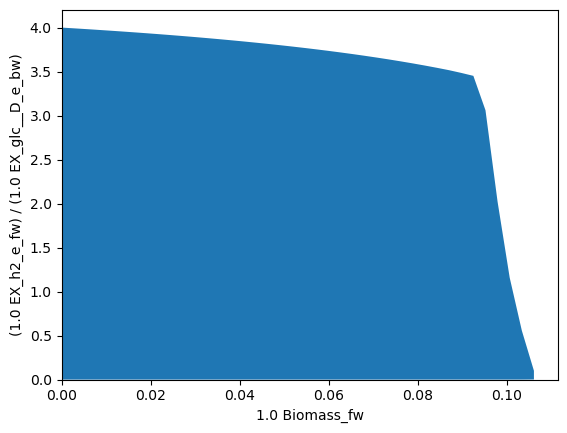

In [3]:
# Visualization of the relationship between H2 synthesis yield and biomass production
sd.plot_flux_space(model_anaero_H2_PFOR, ('Biomass_fw',('EX_h2_e_fw','EX_glc__D_e_bw')));

<div style='text-align: justified'>From the defined flux space, we observe a weakly growth-coupled relationship between the variables, in which biomass maximization does not necessarily require a maximum $H_2$ yield. And so, as demonstrated in previous chapters, the model EC_iCH360_H2_PFOR naturally do not impose $H_2$ yield maximization when biomass is set as the main objective. It is also noteworthy to mention the maximum limit for $H_2$ synthesis yield at 4 mol $H_2$ / mol glucose, which was already suggested by the results generated on Part 8. </div><br>

<div style='text-align: justified'>This way, given the innate capacity of the model for high $H_2$ production yield, we impose an initial lower threshold for product synthesis greater or equal to the minimum value observed in Part 8 for PS2 strain, which corresponds to 3.39 mol $H_2$ / mol glucose. For biomass production, we relax the threshold to half of the maximum observed value, corresponding to 0.056 $h^{-1}$. In this way, we ensure that, through a specific set of enzymatic knockouts, $H_2$ production yield remains above 3.39 mol $H_2$ / mol glucose <b>and</b> biomass production is maintained at a minimum of 0.056 $h^{-1}$. Thus, we aim to enforce the following constraints:</div><br>

<div style='text-align: center'><font size = "4">$\frac{v_{H_2}}{v_{glucose}} \ge 3.39$</font></div><br>

Thus, for the suppress module, we define the inequality:

<div style='text-align: center'><font size = "4">$v_{H_2} - 3.39*v_{glucose} \le 0$</font></div><br>

PS 1: The above-mentioned module has the inequality sign inverted because we aim to suppress it.

<div style='text-align: justified'>Additionally, as a protect module, we aim to ensure that biomass production remains above 0.056 $h^{-1}$, leading to the following inequality:</div><br>

<div style='text-align: center'><font size = "4">$v_{biomass} \ge 0.056$</font></div><br>

<div style='text-align: justified'>Therefore, with the suppress and protect modules defined, we can proceed to visualize the desired flux space.</div><br>

<div style='text-align: justified'><b>PS 2: The rationale behind the construction of these modules can be found in the examples provided on the StrainDesign package <a href="https://github.com/klamt-lab/straindesign/tree/main/docs/source/examples">GitHub page</a>.</b></div> 

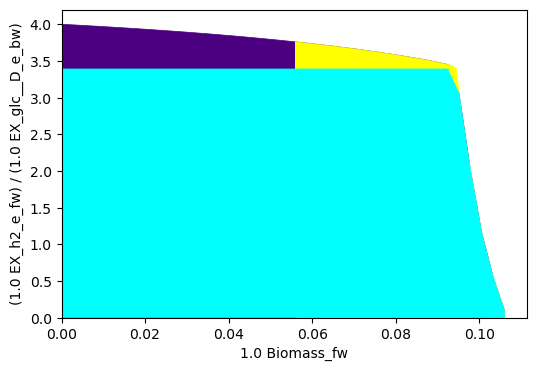

In [5]:
dict_condition_initial = {'Background':('Biomass_fw',('EX_h2_e_fw','EX_glc__D_e_bw')),
                          'Protect':'Biomass_fw >= 0.056',
                          'Suppress': ['EX_h2_e_fw - 3.39 EX_glc__D_e_bw <= 0', 'EX_glc__D_e_bw >= 0.1'],
                          'Knockouts': 0}

dict_colors_initial = {'Background':'indigo',
              'Protect':'yellow',
              'Suppress': 'cyan',
              'Knockouts': 'red'}

f.plot_growth_couple(model_anaero_H2_PFOR,dict_condition_initial,dict_colors_initial,'Growth_Couple_Scenarios.png')

<div style='text-align: justified'> From the graph, we can identify three main regions, with emphasis on the yellow area, which represents the feasible yield space we aim to ensure: biomass production above 0.056 $h^{-1}$ and $H_2$ production yield greater than the established threshold of 3.39 mol $H_2$ / mol glucose.</div><br>

<div style='text-align: justified'> Now, let us first evaluate how the MCS approach performs against the established thresholds.</div>

### 9.1.2 MCS

In [6]:
# modules creation
module_suppress = sd.SDModule(model_anaero_H2_PFOR,sd.SUPPRESS,constraints=['EX_h2_e_fw - 3.39 EX_glc__D_e_bw <= 0', 'EX_glc__D_e_bw >= 0.1'])
module_protect  = sd.SDModule(model_anaero_H2_PFOR,sd.PROTECT, constraints='Biomass_fw >= 0.056')
        
# all reactions have the same weight for knockout
ko_cost = {g.id:1 for g in model_anaero_H2_PFOR.reactions}

sols = sd.compute_strain_designs(model_anaero_H2_PFOR,
                                 sd_modules = [module_suppress,module_protect],
                                 time_limit = 300,
                                 max_solutions = 1,
                                 ko_cost = ko_cost,
                                 max_cost = 10,
                                 solution_approach = sd.names.ANY,
                                 gene_kos = True)

In [7]:
# sols variable could generate equal dictionaries in a list.
# this way, to better visualizate the selected enzymes, we will remove duplicates

unique_values = [dict(d) for d in {frozenset(d.items()) for d in sols.reaction_sd}]
print(unique_values)

[{'ATPS4rpp_fw': -1.0, 'ACALD_bw': -1.0, 'NADH17pp_fw': -1.0, 'PFL_fw': -1.0, 'D_LACtex_bw': -1.0, 'EX_glc__D_e_fw': -1.0, 'GLYCtex_bw': -1.0}]


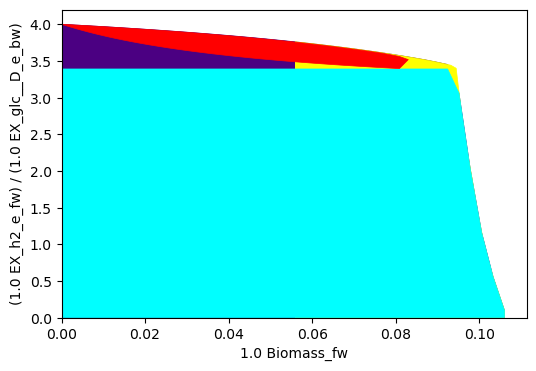

In [39]:
interventions = [[{s:1.0},'=',0.0] for s,v in sols.reaction_sd[0].items() if v < 1]

dict_condition_initial = {'Background':('Biomass_fw',('EX_h2_e_fw','EX_glc__D_e_bw')),
                          'Protect':'Biomass_fw >= 0.056',
                          'Suppress': ['EX_h2_e_fw - 3.39 EX_glc__D_e_bw <= 0', 'EX_glc__D_e_bw >= 0.1'],
                          'Knockouts': interventions}

dict_colors_initial = {'Background':'indigo',
              'Protect':'yellow',
              'Suppress': 'cyan',
              'Knockouts': 'red'}

f.plot_growth_couple(model_anaero_H2_PFOR,dict_condition_initial,dict_colors_initial,'Growth_Couple_MCS_Final.png')

In [5]:
# Maximum yield achieved by the intervetions

with model_anaero_H2_PFOR as m:
    for i in unique_values[0].keys():
        m.reactions.get_by_id(i).bounds = (0,0)

    solution_mcs = m.optimize()

    h2_flux = solution_mcs.fluxes['EX_h2_e_fw']
    yield_h2 = solution_mcs.fluxes['EX_h2_e_fw'] / solution_mcs.fluxes['EX_glc__D_e_bw']

    print(f'H2 production flux after MCS intervetion: {h2_flux}')
    print(f'H2 production yield after MCS intervetion: {yield_h2}')
    print(f'Biomass production after MCS intervetion: {solution_mcs.objective_value}')

H2 production flux after MCS intervetion: 14.879680225389095
H2 production yield after MCS intervetion: 3.517260800077922
Biomass production after MCS intervetion: 0.08301188382569268


<div style='text-align: justified'> By applying the suggested knockout set of the following enzymes: ATPS4rpp_fw, ACALD_bw, NADH17pp_fw, PFL_fw, D_LACtex_bw, EX_glc__D_e_fw, GLYCtex_bw, the model EC_iCH360_H2_PFOR achieves a higher $H_2$ synthesis yield without a substantial loss in biomass production rate. However, before proceeding to a detailed analysis of the selected enzymes, we first evaluate whether $H_2$ synthesis yield can be further maximized.</div><br>

<div style='text-align: justified'>To do this, we will create a function that takes as input the model, the restriction modules, and the initial constraint (here referred to as the product yield constraint), and returns a list of MCS interventions calculated by the algorithm. In each iteration of the function, MCS will be calculated, generating a respective solution to be stored in a dictionary. After each iteration, if a solution is found, the suppress module is updated to a more restrictive value of $H_2$ synthesis yield. The iterations will end when no solution can be found for the established threshold of $H_2$ yield. For the first iteration, we will set the $H_2$ synthesis yield to 3.5 mol $H_2$ / mol glucose, the maximum value obtained by the previously suggested MCS. At each iteration, this value will be increased by 0.1. Additionally, considering the impact of biomass on the analysis, we will relax it further to one quarter of the total biomass synthesis (0.028 $h^{-1}$), which will be kept constant until the iterations conclude.</div>

In [10]:
module_suppress = sd.SDModule(model_anaero_H2_PFOR,sd.SUPPRESS,constraints=['EX_h2_e_fw - 3.5 EX_glc__D_e_bw <= 0', 'EX_glc__D_e_bw >= 0.1'])
module_protect  = sd.SDModule(model_anaero_H2_PFOR,sd.PROTECT, constraints='Biomass_fw >= 0.028')

In [11]:
mcs = f.mcs(model_anaero_H2_PFOR, 3.5, [module_suppress,module_protect])

In [12]:
mcs

{'H2 Yield': [], 'Solution': []}

<div style='text-align: justified'>As indicated by the function, a yield above 3.5 mol $H_2$ / mol glucose is not achievable using the MCS algorithm. However, given the stochastic nature of the method, we cannot confirm that the maximum yield found is the absolute maximum. For the purposes of this analysis, and considering the observed limitations of $H_2$ production yield in the model, we will consider 3.5 mol $H_2$ / mol glucose as the maximum achievable yield. Thus, we proceed to the interpretation of the suggested enzymes.</div>

In [7]:
# Creation of data frames to be used for bar plot generation
limit = 0.01
nadh = 'nadh_c'

df_nadh_PFOR_mcs = f.metabolite_df(model_anaero_H2_PFOR,solution_mcs,nadh,limit)
df_nadh_PFOR_control = f.metabolite_df(model_anaero_H2_PFOR,solution_PFOR_H2,nadh,limit)

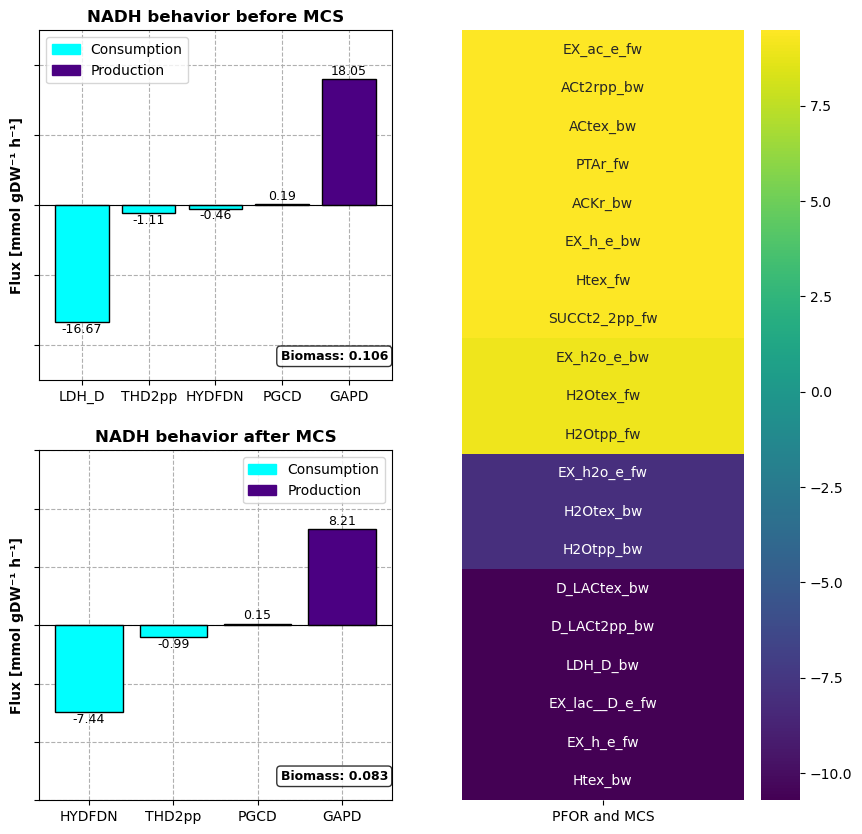

In [ ]:
# Plotting barplot graphs
fig = plt.figure(figsize=(10,10))
gs = GridSpec(2, 2,figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[0:2, 1])

f.plot_df(df_nadh_PFOR_control, 
          "NADH behavior before MCS", 
          [-25,25], 
          round(solution_PFOR_H2.objective_value,4),
          ax=ax1)

f.plot_df(df_nadh_PFOR_mcs, 
          "NADH behavior after MCS", 
          [-15,15], 
          round(solution_mcs.objective_value,4),
          ax=ax2)


# Plotting the heatmaps. The visualization will be restricted to the 20 enzymes showing the greatest variation relative to the control condition.
df_PFOR_mcs_variation = f.enzyme_variation(solution_PFOR_H2, solution_mcs, 20, 'PFOR and MCS')

labels = pd.DataFrame({'Enzymes':df_PFOR_mcs_variation.index})

sns.heatmap(df_PFOR_mcs_variation.iloc[0:20], annot=labels, cmap='viridis',fmt="",yticklabels=False,ax=ax3)

fig.savefig('../Images/NADH_PFOR_MCS.png',dpi=1200)

## 9.3 Strains Comparision

In [3]:
h2_2 = pd.read_csv('../Datasets/h2_2.csv')
h2_PO4 = pd.read_csv('../Datasets/h2_PO4.csv')

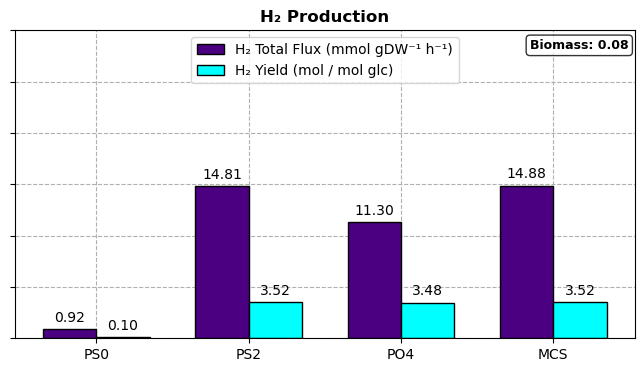

In [31]:
# Creation of the bar plot containing H2 production of strains SP5, SP6, SP7 and PO2
h2_prod_strains = [h2_2, h2_PO4]

h2_flux = [0.9216]
h2_yield = [0.1]

for i in h2_prod_strains:
    h2_data = f.near(i,"Biomass",0.08026049536366127)
    h2_f, h2_y = h2_data[0], h2_data[1]
    
    h2_flux.append(h2_f)
    h2_yield.append(h2_y)

strains = ['PS0','PS2','PO4','MCS']

h2_flux.append(14.88)
h2_yield.append(3.52)

x = np.arange(len(strains))  
width = 0.35

fig, ax = plt.subplots(figsize=(8,4))

rects_1 = ax.bar(x-width/2, h2_flux, width, label='H₂ Total Flux (mmol gDW⁻¹ h⁻¹)', color='indigo', edgecolor='black')
rects_2 = ax.bar(x+width/2, h2_yield, width, label='H₂ Yield (mol / mol glc)', color='cyan', edgecolor='black')

ax.bar_label(rects_1, padding=3, fmt='%.2f')
ax.bar_label(rects_2, padding=3, fmt='%.2f')

#ax.set_ylabel('Flux (mmol/gDW/h)', weight='bold')
ax.set_yticklabels([])
ax.set_ylim(0, 30)
ax.set_xticks(x, strains)
ax.set_title('H₂ Production', weight='bold')
ax.grid(linestyle='dashed')
ax.set_axisbelow(True)

ax.text(
        0.99, 0.93,
        "Biomass: "+str(0.08),         
        ha='right', va='bottom',    
        transform=ax.transAxes,     
        fontsize=9, color="black",
        weight = 'bold',
        bbox=dict(
            boxstyle="round,pad=0.3",   
            facecolor="white",          
            edgecolor="black",          
            alpha=0.8                   
            )
        )

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels , loc='upper center')

plt.show()
fig.savefig('../Images/H2_Strains_bar.png',dpi=1200)

# <b>End of Part 9!</b>